In [1]:
# 타이타닉 호 승객 생존 예측 미니 프로젝트 : (분석&시각화) -> 전처리 -> 머신러닝

In [2]:
import warnings # warnings.py 를 메모리에 올린다.
warnings.filterwarnings('ignore') # 경고 무시

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('titanic.csv')
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pclass     1309 non-null   int64  
 1   survived   1309 non-null   int64  
 2   name       1309 non-null   str    
 3   sex        1309 non-null   str    
 4   age        1046 non-null   float64
 5   sibsp      1309 non-null   int64  
 6   parch      1309 non-null   int64  
 7   ticket     1309 non-null   str    
 8   fare       1308 non-null   float64
 9   cabin      295 non-null    str    
 10  embarked   1307 non-null   str    
 11  boat       486 non-null    str    
 12  body       121 non-null    float64
 13  home.dest  745 non-null    str    
dtypes: float64(3), int64(4), str(7)
memory usage: 143.3 KB


In [6]:
df.describe()

,pclass,survived,age,sibsp,parch,fare,body
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000,121.000000
mean,2.294882,0.381971,29.881135,0.498854,0.385027,33.295479,160.809917
std,0.837836,0.486055,14.413500,1.041658,0.865560,51.758668,97.696922
min,1.000000,0.000000,0.166700,0.000000,0.000000,0.000000,1.000000
25%,2.000000,0.000000,21.000000,0.000000,0.000000,7.895800,72.000000
50%,3.000000,0.000000,28.000000,0.000000,0.000000,14.454200,155.000000
75%,3.000000,1.000000,39.000000,1.000000,0.000000,31.275000,256.000000
max,3.000000,1.000000,80.000000,8.000000,9.000000,512.329200,328.000000


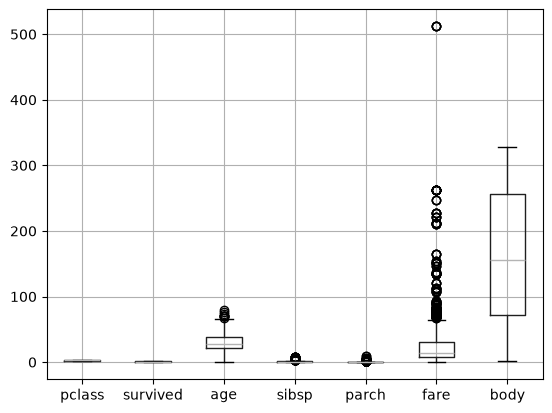

In [7]:
df.boxplot()
plt.show() # 그려라.

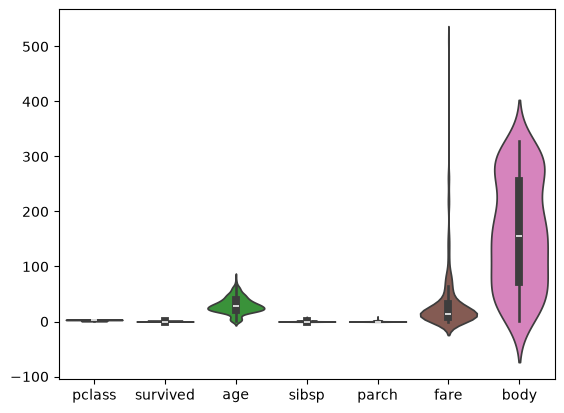

In [8]:
sns.violinplot(df)
plt.savefig('pic01.png')
plt.show()

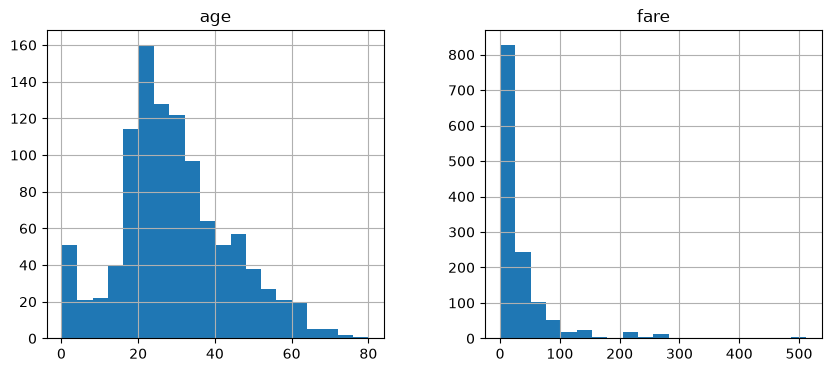

In [9]:
# df[ 조건 ]
df[ ['age', 'fare'] ].hist(figsize=(10,4), bins=20)
plt.show()

In [10]:
# 결측치(null) 갯수 확인

In [11]:
df.isnull()

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False,True,False
2,False,False,False,False,False,False,False,False,False,False,False,True,True,False
3,False,False,False,False,False,False,False,False,False,False,False,True,False,False
4,False,False,False,False,False,False,False,False,False,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,False,False,False,False,False,False,False,False,False,True,False,True,False,True
1305,False,False,False,False,True,False,False,False,False,True,False,True,True,True
1306,False,False,False,False,False,False,False,False,False,True,False,True,False,True
1307,False,False,False,False,False,False,False,False,False,True,False,True,True,True


In [12]:
df.isnull().sum()

pclass          0
survived        0
name            0
sex             0
age           263
sibsp           0
parch           0
ticket          0
fare            1
cabin        1014
embarked        2
boat          823
body         1188
home.dest     564
dtype: int64

In [13]:
# 운임이 결측치인 사람 찾기
# df[ 조건 ]
df[ df['fare'].isnull() ]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
1225,3,0,"Storey, Mr. Thomas",male,60.5,0,0,3701,NaN,NaN,S,NaN,261.0,NaN


In [14]:
# 퀴즈1 : 나이가 75세 이상인 승객 찾기
df[ df['age'] >= 75 ]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
14,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.00,A23,S,B,NaN,"Hessle, Yorks"
61,1,1,"Cavendish, Mrs. Tyrell William (Julia Florence...",female,76.0,1,0,19877,78.85,C46,S,6,NaN,"Little Onn Hall, Staffs"


In [15]:
# 퀴즈2 : 나이가 75세 이상이면서(AND, &) 여성인 승객 찾기
df[ (df['age'] >= 75) & (df['sex'] == 'female') ]

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
61,1,1,"Cavendish, Mrs. Tyrell William (Julia Florence...",female,76.0,1,0,19877,78.85,C46,S,6,NaN,"Little Onn Hall, Staffs"


In [16]:
# 생존자 수와 사망자 수 확인
df['survived'].value_counts()

survived
0    809
1    500
Name: count, dtype: int64

In [17]:
df['sex'].value_counts()

sex
male      843
female    466
Name: count, dtype: int64

In [18]:
df['pclass'].value_counts()

pclass
3    709
1    323
2    277
Name: count, dtype: int64

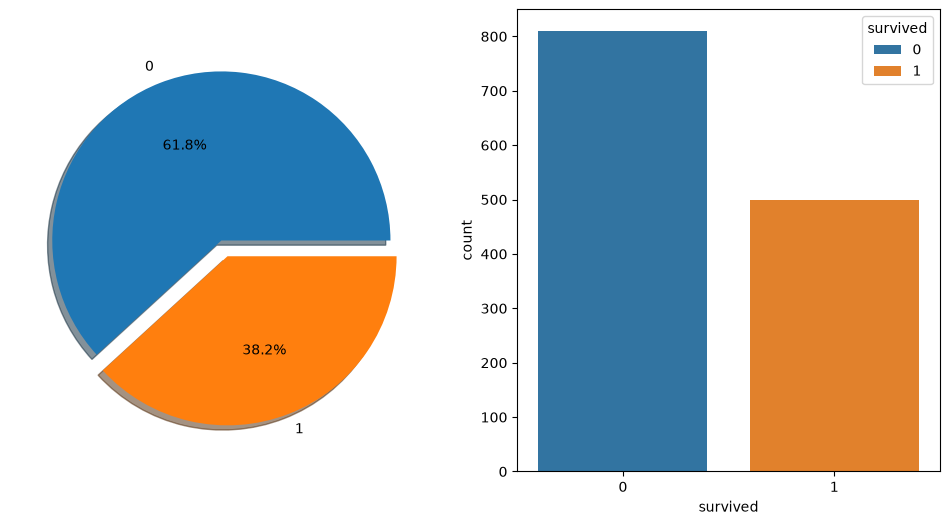

In [19]:
plt.figure(figsize=(12,6))
plt.subplot(121)
df['survived'].value_counts().plot.pie(explode=[0,0.1], autopct="%.1f%%", shadow=True)
plt.subplot(122)
sns.countplot(df, x='survived', hue='survived')
plt.show()

In [20]:
# 그래프 한글깨짐 해결, 원인:디폴트 영문 글꼴 --> 한글 글꼴
import matplotlib.pyplot as plt
import platform
if platform.system() == 'Windows': # W:대문자, 윈도우이면
    plt.rcParams['font.family'] = 'Malgun Gothic' # M,G:대문자, 중간에 스페이스 한칸
elif platform.system() == 'Darwin': # D:대문자, 맥OS이면
    plt.rcParams['font.family'] = 'AppleGothic'
else: # 리눅스
    plt.rcParams['font.family'] = 'NanumGothic'
# -(마이너스 기호) 깨짐 방지 코드
plt.rcParams['axes.unicode_minus'] = False

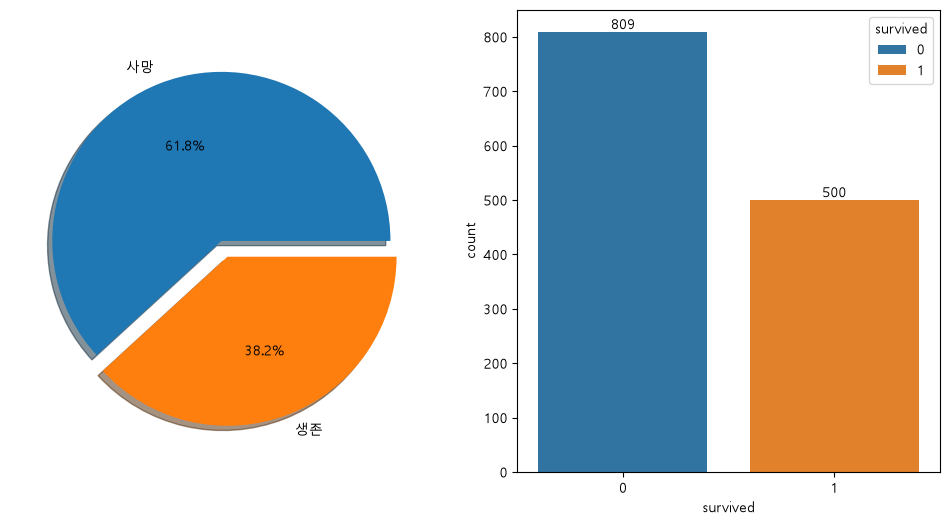

In [21]:
plt.figure(figsize=(12,6))
plt.subplot(121)
df['survived'].value_counts().plot.pie(explode=[0,0.1], autopct="%.1f%%", shadow=True,
                                      labels=['사망','생존'])
plt.subplot(122)
ax = sns.countplot(df, x='survived', hue='survived')
for i in ax.containers:
    ax.bar_label(i)
plt.show()

In [22]:
# 성별에 따른 생존자 수와 사망자 수 확인
df.groupby( ['sex', 'survived'] )['survived'].count()

sex     survived
female  0           127
        1           339
male    0           682
        1           161
Name: survived, dtype: int64

In [23]:
# 성별과 생존여부에 따른 평균
df[ ['sex', 'survived'] ].groupby('sex').mean()

,survived
sex,
female,0.727468
male,0.190985


In [24]:
# 선실등급별 생존 정보 확인
pd.crosstab( df['pclass'], df['survived'] )

survived,0,1
pclass,,
1,123,200
2,158,119
3,528,181


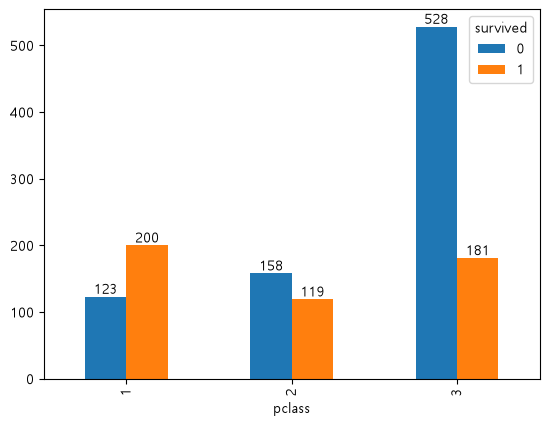

In [25]:
ax = pd.crosstab( df['pclass'], df['survived'] ).plot.bar()
for i in ax.containers:
    ax.bar_label(i)
plt.show()

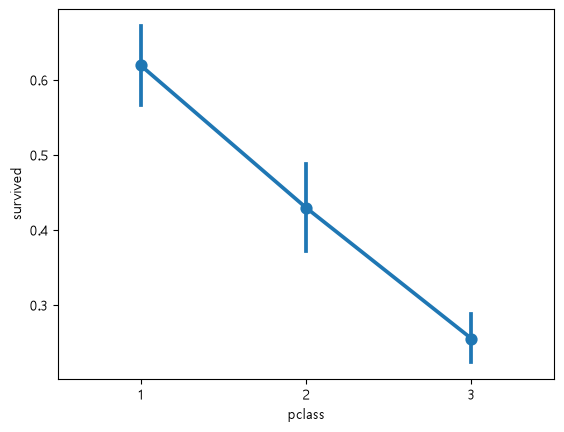

In [26]:
sns.pointplot(df, x='pclass', y='survived')
plt.show()

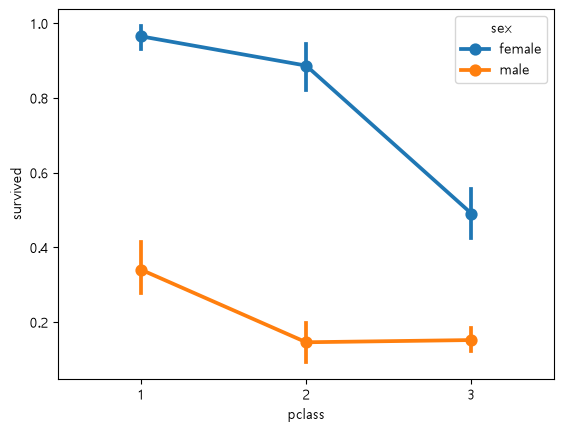

In [27]:
sns.pointplot(df, x='pclass', y='survived', hue='sex')
plt.show()

In [28]:
# 상관계수 확인, -1(반비례) ~ 0(상관없음) ~ 1(비례)
corr = df.corr(numeric_only=True)
corr

,pclass,survived,age,sibsp,parch,fare,body
pclass,1.000000,-0.312469,-0.408106,0.060832,0.018322,-0.558629,-0.034642
survived,-0.312469,1.000000,-0.055513,-0.027825,0.082660,0.244265,NaN
age,-0.408106,-0.055513,1.000000,-0.243699,-0.150917,0.178739,0.058809
sibsp,0.060832,-0.027825,-0.243699,1.000000,0.373587,0.160238,-0.099961
parch,0.018322,0.082660,-0.150917,0.373587,1.000000,0.221539,0.051099
fare,-0.558629,0.244265,0.178739,0.160238,0.221539,1.000000,-0.043110
body,-0.034642,NaN,0.058809,-0.099961,0.051099,-0.043110,1.000000


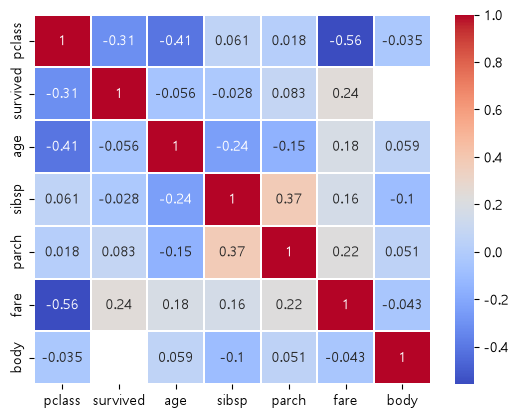

In [29]:
sns.heatmap(corr, linewidths=0.1, annot=True, cmap='coolwarm')
plt.show()

In [30]:
# 선실등급, 성별, 나이(실수 --> 범주형), 운임(실수 --> 범주형)

In [31]:
# 나이(실수 --> 범주형, 연령대)
# df['추가할_컬럼명'] = pd.cut(컬럼, 범위, 라벨)
df['age_cat'] = pd.cut(df['age'], bins=[0,5,12,19,39,59,80],
                      labels=['애기','어린이','청소년','청년','중년','노년'])
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,age_cat
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",청년
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",애기
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",애기
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",청년
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",청년
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN,청소년
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN,NaN
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN,청년
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN,청년


In [32]:
# 운임(실수 --> 범주형, 운임대)
bins = [ -1, 10, 30, 100, 600 ] # -1을 쓴 이유, 0을 쓰면 0은 안 포함돼서 ==> 0~10
labels = [ 'low', 'medium', 'high', 'veryhigh' ]
df['fare_cat'] = pd.cut(df['fare'], bins=bins, labels=labels)
df

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,age_cat,fare_cat
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",청년,veryhigh
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",애기,veryhigh
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",애기,veryhigh
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",청년,veryhigh
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",청년,veryhigh
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,NaN,328.0,NaN,청소년,medium
1305,3,0,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,NaN,NaN,NaN,NaN,medium
1306,3,0,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,NaN,304.0,NaN,청년,low
1307,3,0,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,NaN,NaN,NaN,청년,low


In [33]:
# 결론 : 최종 그래프(선실등급, 연령대, 성별, 운임대에 따른 생존 정보 그래프)

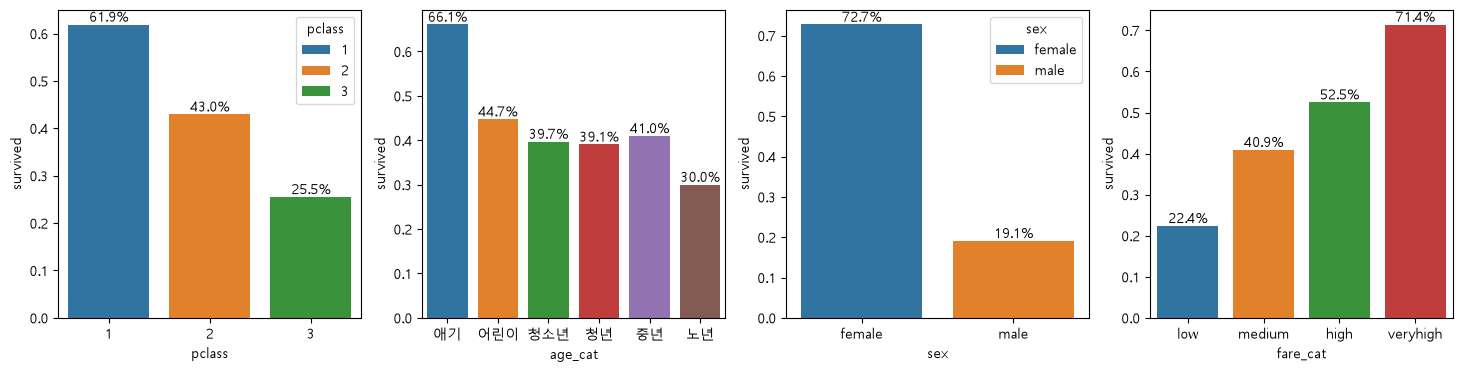

In [34]:
plt.figure(figsize=(18,4))
plt.subplot(141)
ax = sns.barplot(df, x='pclass', y='survived', errorbar=None, hue='pclass', palette='tab10')
for i in ax.containers:
    ax.bar_label(i, fmt="{:.1%}")
plt.subplot(142)
ax = sns.barplot(df, x='age_cat', y='survived', errorbar=None, hue='age_cat', palette='tab10', dodge=False, legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="{:.1%}")
plt.subplot(143)
ax = sns.barplot(df, x='sex', y='survived', errorbar=None, hue='sex', palette='tab10', dodge=False, legend=True)
for i in ax.containers:
    ax.bar_label(i, fmt="{:.1%}")
plt.subplot(144)
ax = sns.barplot(df, x='fare_cat', y='survived', errorbar=None, hue='fare_cat', palette='tab10', dodge=False, legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="{:.1%}")
plt.show()

In [35]:
# end